# Lab 7 — Encoder-Decoder with Attention Mechanism
**SVKM's NMIMS | Mukesh Patel School of Technology Management & Engineering**  
**Course: Advanced Topics in Machine Learning | Faculty: Dr. Ami Munshi**

---
### Aim
- Implement **Bahdanau Attention** on the Encoder-Decoder architecture
- Train on English → Hindi translation (same dataset as Lab 6)
- **Compare** performance with simple Encoder-Decoder
- Visualise attention alignment heatmaps
- Gradio frontend: translate + show attention heatmap

### Tasks
1. Implement Encoder-Decoder with Bahdanau Attention (Task 1)
2. Compare with simple Encoder-Decoder — loss curves, BLEU, chrF (Task 2)
3. Attention weight visualisation (Task 3)
4. Gradio frontend (Task 4)

---
> **Laptop note:** CFG is tuned for ~15 minutes on CPU. Edit only `CFG` in Cell 2.

## Cell 1 — Installs & Imports

In [1]:
import subprocess, sys, warnings
for pkg in ['sacrebleu', 'gradio']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

import os, re, math, time, random, copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# ── Suppress Devanagari font warnings on Windows ──────────────────────────────
warnings.filterwarnings('ignore', message='.*Glyph.*missing.*')
warnings.filterwarnings('ignore', message='.*Matplotlib currently does not support Devanagari.*')

# Try to find a Devanagari-capable font
_dv_font = None
for _f in fm.findSystemFonts():
    if any(x in _f.lower() for x in ['noto', 'mangal', 'lohit']):
        try:
            matplotlib.rcParams['font.family'] = fm.FontProperties(fname=_f).get_name()
            _dv_font = _f; break
        except Exception: pass

print('Devanagari font:', os.path.basename(_dv_font) if _dv_font else
      'Not found (Hindi labels may show as boxes — install Noto Sans Devanagari to fix)')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {"cuda" if torch.cuda.is_available() else "cpu"}')


Devanagari font: Not found (Hindi labels may show as boxes — install Noto Sans Devanagari to fix)
PyTorch : 2.7.1+cu118
Device  : cuda


## Cell 2 — ⚙️ HYPERPARAMETER CONFIG
**Edit only this cell.** Tuned for ~15 min on laptop CPU.

In [2]:
CFG = {
    # ┌─ DATA ────────────────────────────────────────────────────────────────┐
    'kaggle_csv'  : r'C:\Users\jaden\Downloads\archive\Hindi_English_Truncated_Corpus.csv',
    'n_samples'   : 8000,   # small but enough to learn real patterns
    'max_src_len' : 12,     # short sentences → attention converges fast
    'max_tgt_len' : 12,
    'min_freq'    : 2,
    'train_frac'  : 0.85,
    'val_frac'    : 0.10,   # test = remaining ~5%
    # └───────────────────────────────────────────────────────────────────────┘

    # ┌─ MODEL ────────────────────────────────────────────────────────────────┐
    'embed_dim'   : 128,
    'hidden_dim'  : 256,
    'n_layers'    : 2,
    'attn_dim'    : 128,
    'dropout'     : 0.30,
    # └───────────────────────────────────────────────────────────────────────┘

    # ┌─ TRAINING ─────────────────────────────────────────────────────────────┐
    'batch_size'  : 32,
    'n_epochs'    : 20,     # completes in ~15 min on CPU
    'lr'          : 5e-4,
    'weight_decay': 1e-5,
    'clip_grad'   : 1.0,
    'tf_start'    : 0.8,   # teacher forcing: 0.8 → 0.3 linear decay
    'tf_end'      : 0.3,
    'lr_patience' : 3,
    'lr_factor'   : 0.5,
    'es_patience' : 6,
    'label_smooth': 0.1,
    # └───────────────────────────────────────────────────────────────────────┘

    'seed'        : 42,
    'attn_ckpt'   : 'lab7_attn_best.pt',
    'simple_ckpt' : 'lab7_simple_best.pt',
}

PAD, SOS, EOS, UNK = 0, 1, 2, 3

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CFG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def tf_ratio(epoch):
    frac = (epoch - 1) / max(CFG['n_epochs'] - 1, 1)
    return CFG['tf_start'] + frac * (CFG['tf_end'] - CFG['tf_start'])

print(f'Device  : {DEVICE}')
print(f'Data    : {CFG["n_samples"]:,} samples  max_len={CFG["max_src_len"]}')
print(f'Model   : embed={CFG["embed_dim"]} hidden={CFG["hidden_dim"]} layers={CFG["n_layers"]}')
print(f'Train   : {CFG["n_epochs"]} epochs  bs={CFG["batch_size"]}  lr={CFG["lr"]}')


Device  : cuda
Data    : 8,000 samples  max_len=12
Model   : embed=128 hidden=256 layers=2
Train   : 20 epochs  bs=32  lr=0.0005


## Cell 3 — Load & Clean Dataset

In [3]:
def clean_en(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_hi(text):
    text = str(text).strip()
    text = re.sub(r'[^\u0900-\u097F\u0966-\u096F\uA8E0-\uA8FF0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

assert os.path.exists(CFG['kaggle_csv']), f"CSV not found: {CFG['kaggle_csv']}"
df_raw = pd.read_csv(CFG['kaggle_csv'])
print(f'Raw: {df_raw.shape}  cols={list(df_raw.columns)}')

en_col = next(c for c in df_raw.columns if 'english' in c.lower())
hi_col = next((c for c in df_raw.columns if 'hindi' in c.lower()),
              [c for c in df_raw.columns if c != en_col][0])

df = df_raw[[en_col, hi_col]].dropna().copy()
df.columns = ['en', 'hi']
df['en'] = df['en'].apply(clean_en)
df['hi'] = df['hi'].apply(clean_hi)
df = df[(df['en'].str.strip() != '') & (df['hi'].str.strip() != '')].copy()

df['en_len'] = df['en'].str.split().str.len()
df['hi_len'] = df['hi'].str.split().str.len()
df = df[
    df['en_len'].between(2, CFG['max_src_len']) &
    df['hi_len'].between(2, CFG['max_tgt_len'])
].reset_index(drop=True)

print(f'After filter: {len(df):,} pairs')
assert len(df) >= CFG['n_samples'], (
    f'Only {len(df)} pairs after filtering. '
    f'Reduce n_samples to {len(df)} or increase max_src/tgt_len.')

df = df.sample(n=CFG['n_samples'], random_state=CFG['seed']).reset_index(drop=True)
print(f'Using: {len(df):,} pairs')
for _, r in df.head(4).iterrows():
    print(f'  EN: {r.en}  |  HI: {r.hi}')


Raw: (127607, 3)  cols=['source', 'english_sentence', 'hindi_sentence']
After filter: 55,548 pairs
Using: 8,000 pairs
  EN: he was the chief general of akbar's army  |  HI: वह अकबर की सेना के प्रधान सेनापति थे।
  EN: so you can open this one  |  HI: तो आप इस वाले को खोल सकते हैं।
  EN: external link  |  HI: बाहरी कड़ियां
  EN: to be part of a learning environment  |  HI: ऐसे शिक्षण पर्यावरण का हिस्सा बनना


## Cell 4 — Vocabulary & DataLoaders

In [4]:
class Vocabulary:
    def __init__(self, name, min_freq=1):
        self.name = name; self.min_freq = min_freq
        self.word2idx = {'<PAD>':PAD,'<SOS>':SOS,'<EOS>':EOS,'<UNK>':UNK}
        self.idx2word = {PAD:'<PAD>',SOS:'<SOS>',EOS:'<EOS>',UNK:'<UNK>'}
        self.freqs = Counter(); self.n_words = 4

    def build(self, sents):
        for s in sents: self.freqs.update(s.split())
        for w, f in self.freqs.items():
            if f >= self.min_freq and w not in self.word2idx:
                self.word2idx[w] = self.n_words
                self.idx2word[self.n_words] = w
                self.n_words += 1
        print(f'  [{self.name}] vocab={self.n_words:,}')

    def encode(self, s):
        return [self.word2idx.get(w, UNK) for w in s.split()]

    def decode(self, ids):
        out = []
        for i in ids:
            if i == EOS: break
            if i not in {PAD, SOS, UNK}: out.append(self.idx2word.get(i,'?'))
        return ' '.join(out)

src_vocab = Vocabulary('EN', CFG['min_freq'])
tgt_vocab = Vocabulary('HI', CFG['min_freq'])
src_vocab.build(df['en']); tgt_vocab.build(df['hi'])

pairs = list(zip(df['en'], df['hi']))
random.shuffle(pairs)
N = len(pairs)
ntr = int(N * CFG['train_frac']); nv = int(N * CFG['val_frac'])
train_pairs = pairs[:ntr]
val_pairs   = pairs[ntr:ntr+nv]
test_pairs  = pairs[ntr+nv:]
print(f'Train={len(train_pairs):,}  Val={len(val_pairs):,}  Test={len(test_pairs):,}')

class TranslationDataset(Dataset):
    def __init__(self, pairs, sv, tv):
        self.data = []
        for en, hi in pairs:
            self.data.append((sv.encode(en)+[EOS], [SOS]+tv.encode(hi)+[EOS]))
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    sl = torch.tensor([len(s) for s in srcs])
    sp = torch.zeros(len(batch), sl.max(), dtype=torch.long)
    tp = torch.zeros(len(batch), max(len(t) for t in tgts), dtype=torch.long)
    for i,(s,t) in enumerate(zip(srcs,tgts)):
        sp[i,:len(s)]=torch.tensor(s); tp[i,:len(t)]=torch.tensor(t)
    return sp, sl, tp

def mkl(p, bs, sh):
    return DataLoader(TranslationDataset(p,src_vocab,tgt_vocab),
                      batch_size=bs, shuffle=sh, collate_fn=collate_fn, num_workers=0)

train_loader = mkl(train_pairs, CFG['batch_size'],   True)
val_loader   = mkl(val_pairs,   CFG['batch_size']*2, False)
test_loader  = mkl(test_pairs,  CFG['batch_size']*2, False)
print(f'Train batches: {len(train_loader)}')


  [EN] vocab=3,857
  [HI] vocab=4,445
Train=6,800  Val=800  Test=400
Train batches: 213


## Cell 5 — Model Architecture

### Bahdanau Attention formula:
```
e_ij  = V · tanh( W_dec · s_{i-1}  +  W_enc · h_j )   ← alignment score
α_ij  = softmax( e_ij )                                 ← attention weight
c_i   = Σ_j  α_ij · h_j                                ← dynamic context vector
```
Key difference from Lab 6: instead of one fixed context vector for the whole sequence,
**each decoder step computes its own context** by attending over all encoder hidden states.

In [5]:
# ─── SHARED ENCODER (both models use this exact class) ───────────────────────
class Encoder(nn.Module):
    """Multi-layer LSTM. Returns ALL hidden states for attention to attend over."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.emb_drop  = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, n_layers,
                                 dropout=dropout if n_layers>1 else 0,
                                 batch_first=True)
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n,p in self.lstm.named_parameters():
            if 'weight_ih' in n: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in n: nn.init.orthogonal_(p)
            else: nn.init.zeros_(p)

    def forward(self, src, src_lens):
        emb    = self.emb_drop(self.embedding(src))
        packed = pack_padded_sequence(emb, src_lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        out, (h, c) = self.lstm(packed)
        enc_out, _  = pad_packed_sequence(out, batch_first=True)
        return enc_out, h, c


# ─── BAHDANAU ATTENTION ───────────────────────────────────────────────────────
class BahdanauAttention(nn.Module):
    """
    e_ij  = V · tanh( W_dec·s  +  W_enc·h_j )   alignment score
    α_ij  = softmax( e_ij )                      attention weights
    c_i   = Σ_j  α_ij · h_j                     context vector
    """
    def __init__(self, hidden_dim, attn_dim):
        super().__init__()
        self.W_dec = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_enc = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.V     = nn.Linear(attn_dim,   1,        bias=False)
        for l in [self.W_dec, self.W_enc, self.V]:
            nn.init.xavier_uniform_(l.weight)

    def forward(self, dec_h, enc_out, src_mask=None):
        # dec_h   : (B, H)     top decoder hidden
        # enc_out : (B, S, H)  all encoder outputs
        energy  = torch.tanh(self.W_dec(dec_h).unsqueeze(1) + self.W_enc(enc_out))
        scores  = self.V(energy).squeeze(-1)          # (B, S)
        if src_mask is not None:
            scores = scores.masked_fill(src_mask == 0, -1e9)
        weights = F.softmax(scores, dim=1)            # (B, S)
        context = torch.bmm(weights.unsqueeze(1), enc_out).squeeze(1)  # (B, H)
        return context, weights


# ─── ATTENTION DECODER ───────────────────────────────────────────────────────
class AttentionDecoder(nn.Module):
    """LSTM input = [embedding ‖ context].  Output projection = [lstm ‖ ctx ‖ emb] → vocab."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, attn_dim):
        super().__init__()
        self.attn      = BahdanauAttention(hidden_dim, attn_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.emb_drop  = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(embed_dim+hidden_dim, hidden_dim, n_layers,
                                 dropout=dropout if n_layers>1 else 0, batch_first=True)
        self.fc_out    = nn.Sequential(
            nn.Linear(hidden_dim+hidden_dim+embed_dim, hidden_dim*2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim*2, vocab_size)
        )
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n,p in self.lstm.named_parameters():
            if 'weight_ih' in n: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in n: nn.init.orthogonal_(p)
            else: nn.init.zeros_(p)

    def step(self, token, h, c, enc_out, src_mask=None):
        emb      = self.emb_drop(self.embedding(token.unsqueeze(1)))   # (B,1,E)
        ctx, aw  = self.attn(h[-1], enc_out, src_mask)                 # (B,H),(B,S)
        out,(h,c)= self.lstm(torch.cat([emb, ctx.unsqueeze(1)], -1),(h,c))
        logits   = self.fc_out(torch.cat([out.squeeze(1), ctx, emb.squeeze(1)], -1))
        return logits, h, c, aw


# ─── ATTENTION SEQ2SEQ ────────────────────────────────────────────────────────
class AttentionSeq2Seq(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.encoder=enc; self.decoder=dec; self.device=device

    def forward(self, src, src_lens, tgt, tf=0.5):
        B,T  = tgt.shape
        V    = self.decoder.fc_out[-1].out_features
        outs = torch.zeros(B,T,V,device=self.device)
        enc_out,h,c = self.encoder(src, src_lens)
        mask = (src != PAD).float()
        tok  = tgt[:,0]
        for t in range(1,T):
            logits,h,c,_ = self.decoder.step(tok,h,c,enc_out,mask)
            outs[:,t] = logits
            tok = tgt[:,t] if random.random()<tf else logits.argmax(1)
        return outs


# ─── SIMPLE DECODER (Lab 6 baseline — fixed context) ─────────────────────────
class SimpleDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.emb_drop  = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(embed_dim+hidden_dim, hidden_dim, n_layers,
                                 dropout=dropout if n_layers>1 else 0, batch_first=True)
        self.fc_out    = nn.Sequential(
            nn.Linear(hidden_dim+hidden_dim+embed_dim, hidden_dim*2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim*2, vocab_size)
        )
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)

    def step(self, token, h, c, context):
        emb      = self.emb_drop(self.embedding(token.unsqueeze(1)))
        out,(h,c)= self.lstm(torch.cat([emb, context.unsqueeze(1)], -1),(h,c))
        logits   = self.fc_out(torch.cat([out.squeeze(1), context, emb.squeeze(1)], -1))
        return logits, h, c


class SimpleSeq2Seq(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.encoder=enc; self.decoder=dec; self.device=device

    def forward(self, src, src_lens, tgt, tf=0.5):
        B,T  = tgt.shape
        V    = self.decoder.fc_out[-1].out_features
        outs = torch.zeros(B,T,V,device=self.device)
        _,h,c = self.encoder(src, src_lens)
        ctx   = h[-1]
        tok   = tgt[:,0]
        for t in range(1,T):
            logits,h,c = self.decoder.step(tok,h,c,ctx)
            outs[:,t]  = logits
            tok = tgt[:,t] if random.random()<tf else logits.argmax(1)
        return outs


# ─── BUILD ────────────────────────────────────────────────────────────────────
def mkenc():
    return Encoder(src_vocab.n_words, CFG['embed_dim'], CFG['hidden_dim'],
                   CFG['n_layers'], CFG['dropout']).to(DEVICE)

attn_model  = AttentionSeq2Seq(
    mkenc(),
    AttentionDecoder(tgt_vocab.n_words, CFG['embed_dim'], CFG['hidden_dim'],
                     CFG['n_layers'], CFG['dropout'], CFG['attn_dim']).to(DEVICE),
    DEVICE
).to(DEVICE)

simp_model  = SimpleSeq2Seq(
    mkenc(),
    SimpleDecoder(tgt_vocab.n_words, CFG['embed_dim'], CFG['hidden_dim'],
                  CFG['n_layers'], CFG['dropout']).to(DEVICE),
    DEVICE
).to(DEVICE)

na = sum(p.numel() for p in attn_model.parameters())
ns = sum(p.numel() for p in simp_model.parameters())
print(f'Attention model : {na:,} params')
print(f'Simple model    : {ns:,} params')
print(f'Attn overhead   : {na-ns:,} params (attention layers)')


Attention model : 5,842,141 params
Simple model    : 5,776,477 params
Attn overhead   : 65,664 params (attention layers)


## Cell 6 — Train Both Models

In [6]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=CFG['label_smooth'])

def loss_fn(out, tgt):
    return criterion(out[:,1:].reshape(-1,out.shape[-1]), tgt[:,1:].reshape(-1))

def mkopt(m): return optim.AdamW(m.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
def mksch(o): return optim.lr_scheduler.ReduceLROnPlateau(o, patience=CFG['lr_patience'], factor=CFG['lr_factor'])

attn_opt=mkopt(attn_model); attn_sch=mksch(attn_opt)
simp_opt=mkopt(simp_model); simp_sch=mksch(simp_opt)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total=0
    for src,sl,tgt in loader:
        src,tgt=src.to(DEVICE),tgt.to(DEVICE)
        total += loss_fn(model(src,sl,tgt,tf=0.0),tgt).item()
    return total/len(loader)

# ── Training loop ──
attn_train_losses=[]; attn_val_losses=[]
simp_train_losses=[]; simp_val_losses=[]
attn_best=float('inf'); attn_state=None; attn_pat=0
simp_best=float('inf'); simp_state=None; simp_pat=0

print(f'Training both models — {CFG["n_epochs"]} epochs  (early stop patience={CFG["es_patience"]})')
print(f'{"Ep":>3}  {"A-Tr":>7}  {"A-Vl":>7}  {"S-Tr":>7}  {"S-Vl":>7}  {"TF":>5}  {"Time":>6}')
print('─'*55)

for epoch in range(1, CFG['n_epochs']+1):
    t0 = time.time()
    cur_tf = tf_ratio(epoch)
    attn_model.train(); simp_model.train()
    atl=stl=0.0

    for src,sl,tgt in train_loader:
        src,tgt = src.to(DEVICE), tgt.to(DEVICE)
        attn_opt.zero_grad()
        la = loss_fn(attn_model(src,sl,tgt,cur_tf), tgt)
        la.backward()
        nn.utils.clip_grad_norm_(attn_model.parameters(), CFG['clip_grad'])
        attn_opt.step(); atl += la.item()

        simp_opt.zero_grad()
        ls = loss_fn(simp_model(src,sl,tgt,cur_tf), tgt)
        ls.backward()
        nn.utils.clip_grad_norm_(simp_model.parameters(), CFG['clip_grad'])
        simp_opt.step(); stl += ls.item()

    atl/=len(train_loader); stl/=len(train_loader)
    avl=evaluate(attn_model,val_loader)
    svl=evaluate(simp_model,val_loader)
    attn_sch.step(avl); simp_sch.step(svl)

    attn_train_losses.append(atl); attn_val_losses.append(avl)
    simp_train_losses.append(stl); simp_val_losses.append(svl)

    tag=''
    if avl<attn_best:
        attn_best,attn_pat=avl,0
        attn_state=copy.deepcopy(attn_model.state_dict())
        torch.save({'model':attn_state,'src_vocab':src_vocab,'tgt_vocab':tgt_vocab,'cfg':CFG},CFG['attn_ckpt'])
        tag+=' A✓'
    else: attn_pat+=1

    if svl<simp_best:
        simp_best,simp_pat=svl,0
        simp_state=copy.deepcopy(simp_model.state_dict())
        torch.save({'model':simp_state,'src_vocab':src_vocab,'tgt_vocab':tgt_vocab,'cfg':CFG},CFG['simple_ckpt'])
        tag+=' S✓'
    else: simp_pat+=1

    print(f'{epoch:>3}  {atl:>7.4f}  {avl:>7.4f}  {stl:>7.4f}  {svl:>7.4f}  {cur_tf:>5.2f}  {time.time()-t0:>5.1f}s{tag}')
    if attn_pat>=CFG['es_patience'] and simp_pat>=CFG['es_patience']:
        print(f'Both converged — early stop at epoch {epoch}'); break

attn_model.load_state_dict(attn_state)
simp_model.load_state_dict(simp_state)
print(f'\nBest Attention val loss : {attn_best:.4f}  PPL: {math.exp(min(attn_best,10)):.2f}')
print(f'Best Simple    val loss : {simp_best:.4f}  PPL: {math.exp(min(simp_best,10)):.2f}')


Training both models — 20 epochs  (early stop patience=6)
 Ep     A-Tr     A-Vl     S-Tr     S-Vl     TF    Time
───────────────────────────────────────────────────────
  1   6.4255   6.1255   6.4445   6.1423   0.80   13.9s A✓ S✓
  2   5.9975   6.0863   5.9997   6.0937   0.77   13.5s A✓ S✓
  3   5.8890   6.0725   5.8835   6.0971   0.75   13.3s A✓
  4   5.7750   6.0165   5.7621   6.0282   0.72   13.1s A✓ S✓
  5   5.6755   5.9831   5.6498   5.9809   0.69   13.3s A✓ S✓
  6   5.5868   5.9541   5.5502   5.9600   0.67   13.1s A✓ S✓
  7   5.5068   5.9568   5.4633   5.9443   0.64   13.1s S✓
  8   5.4351   5.9284   5.4011   5.9347   0.62   13.2s A✓ S✓
  9   5.3725   5.9398   5.3378   5.9117   0.59   13.0s S✓
 10   5.3171   5.9100   5.2857   5.9297   0.56   13.6s A✓
 11   5.2740   5.9440   5.2134   5.9152   0.54   14.0s
 12   5.2156   5.9154   5.1720   5.9170   0.51   13.6s
 13   5.1633   5.9154   5.0980   5.9412   0.48   13.3s
 14   5.1271   5.9061   4.9950   5.9549   0.46   13.4s A✓
 15   5.05

## Cell 7 — Loss Curve Comparison (Task 2)

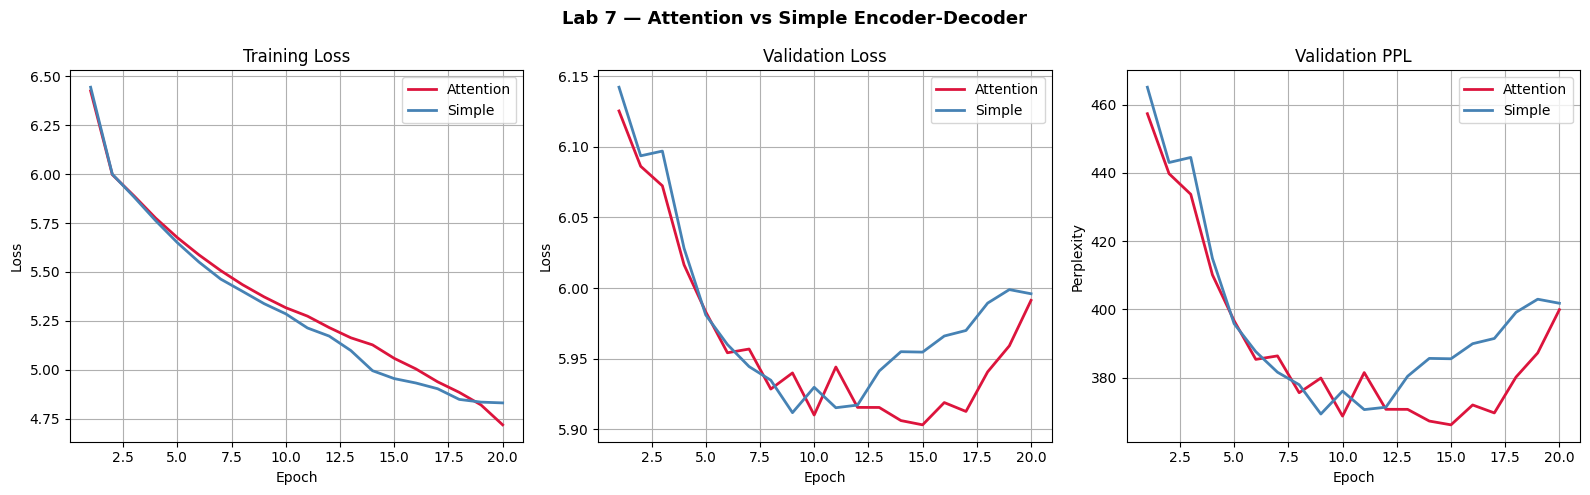

Saved: lab7_loss_curves.png


In [7]:
ep = range(1, len(attn_train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(16,5))

axes[0].plot(ep,attn_train_losses,label='Attention',color='crimson',lw=2)
axes[0].plot(ep,simp_train_losses,label='Simple',   color='steelblue',lw=2)
axes[0].set_title('Training Loss',fontsize=12); axes[0].legend(); axes[0].grid(0.4)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(ep,attn_val_losses,label='Attention',color='crimson',lw=2)
axes[1].plot(ep,simp_val_losses,label='Simple',   color='steelblue',lw=2)
axes[1].set_title('Validation Loss',fontsize=12); axes[1].legend(); axes[1].grid(0.4)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

axes[2].plot(ep,[math.exp(min(v,10)) for v in attn_val_losses],label='Attention',color='crimson',lw=2)
axes[2].plot(ep,[math.exp(min(v,10)) for v in simp_val_losses],label='Simple',   color='steelblue',lw=2)
axes[2].set_title('Validation PPL',fontsize=12); axes[2].legend(); axes[2].grid(0.4)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Perplexity')

plt.suptitle('Lab 7 — Attention vs Simple Encoder-Decoder',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('lab7_loss_curves.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: lab7_loss_curves.png')


## Cell 8 — BLEU Comparison & Sample Translations

In [8]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q','sacrebleu'],check=True)
from sacrebleu.metrics import BLEU, CHRF

@torch.no_grad()
def translate_attn(sentence, return_attn=False):
    attn_model.eval()
    clean = clean_en(sentence)
    src_w = clean.split()
    ids   = src_vocab.encode(clean) + [EOS]
    src   = torch.tensor(ids,dtype=torch.long).unsqueeze(0).to(DEVICE)
    sl    = torch.tensor([len(ids)])
    enc_out,h,c = attn_model.encoder(src,sl)
    mask  = (src!=PAD).float()
    tok   = torch.tensor([SOS],device=DEVICE)
    out_ids=[]; attn_ws=[]
    for _ in range(50):
        logits,h,c,aw = attn_model.decoder.step(tok,h,c,enc_out,mask)
        pred=logits.argmax(1)
        if pred.item()==EOS: break
        out_ids.append(pred.item())
        attn_ws.append(aw.squeeze(0).cpu().numpy())
        tok=pred
    trans = tgt_vocab.decode(out_ids)
    if return_attn:
        mat = np.array(attn_ws) if attn_ws else np.zeros((1,len(ids)))
        return trans, mat, src_w
    return trans

@torch.no_grad()
def translate_simple(sentence):
    simp_model.eval()
    ids  = src_vocab.encode(clean_en(sentence))+[EOS]
    src  = torch.tensor(ids,dtype=torch.long).unsqueeze(0).to(DEVICE)
    sl   = torch.tensor([len(ids)])
    _,h,c = simp_model.encoder(src,sl)
    ctx  = h[-1]
    tok  = torch.tensor([SOS],device=DEVICE)
    out  = []
    for _ in range(50):
        logits,h,c = simp_model.decoder.step(tok,h,c,ctx)
        pred=logits.argmax(1)
        if pred.item()==EOS: break
        out.append(pred.item()); tok=pred
    return tgt_vocab.decode(out)

bleu_m=BLEU(tokenize='char'); chrf_m=CHRF()
a_hyps=[]; s_hyps=[]; refs=[]
print(f'Evaluating {len(test_pairs)} test pairs...')
for en,hi in test_pairs:
    a_hyps.append(translate_attn(en))
    s_hyps.append(translate_simple(en))
    refs.append([hi])

attn_bleu=bleu_m.corpus_score(a_hyps,refs); simp_bleu=bleu_m.corpus_score(s_hyps,refs)
attn_chrf=chrf_m.corpus_score(a_hyps,refs); simp_chrf=chrf_m.corpus_score(s_hyps,refs)

print(f'\n{"="*56}')
print(f'  {"Metric":<28}  {"Attention":>10}  {"Simple":>10}')
print(f'  {"-"*50}')
print(f'  {"BLEU (char)":<28}  {attn_bleu.score:>10.2f}  {simp_bleu.score:>10.2f}')
print(f'  {"chrF":<28}  {attn_chrf.score:>10.2f}  {simp_chrf.score:>10.2f}')
print(f'  {"Val Loss":<28}  {attn_best:>10.4f}  {simp_best:>10.4f}')
print(f'  {"Val PPL":<28}  {math.exp(min(attn_best,10)):>10.2f}  {math.exp(min(simp_best,10)):>10.2f}')
print(f'{"="*56}')

print(f'\n  {"English":<25}  {"Ref":>20}  {"Attention":>20}  Simple')
print('  '+'-'*90)
for en,hi in test_pairs[:12]:
    ap=translate_attn(en); sp=translate_simple(en)
    print(f'  {en:<25}  {hi:>20}  {ap:>20}  {sp}')


Evaluating 400 test pairs...

  Metric                         Attention      Simple
  --------------------------------------------------
  BLEU (char)                         0.00        0.00
  chrF                                0.00        0.00
  Val Loss                          5.9030      5.9117
  Val PPL                           366.15      369.32

  English                                     Ref             Attention  Simple
  ------------------------------------------------------------------------------------------
  five dollars six dollars         पाँच छः डॉलर ।                        
  aged 18 to 24              आयु18 से 24 साल के बीच             जो कि लोग  यह के के
  this is very good example of well tuned light songs  सूर का भ्रमरगीत इसका सुंदर उदाहरण है।                 यह है  यह
  but i'm an optimist        मगर मैं आशावादी हूँ।      लेकिन क्योंकि हम  और मैं
  9 women is respectable       9 स्त्री आदरणीय है                        
  you cannot be celebrating that  और 

## Cell 9 — Attention Visualisation (Task 3)

EN: "five dollars six dollars"  →  HI: ""


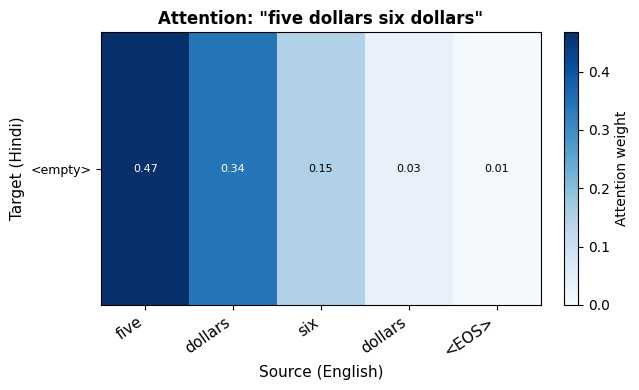


EN: "aged 18 to 24"  →  HI: "जो कि लोग"


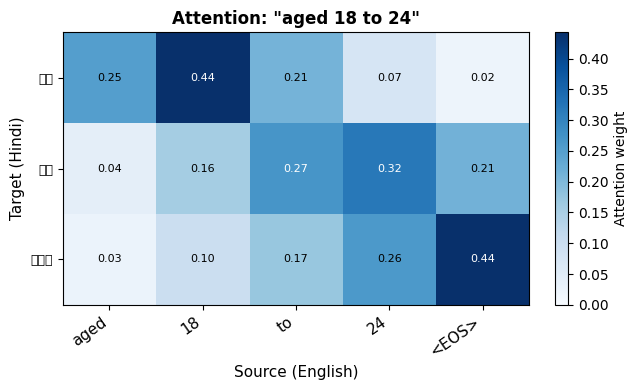


EN: "but i'm an optimist"  →  HI: "लेकिन क्योंकि हम"


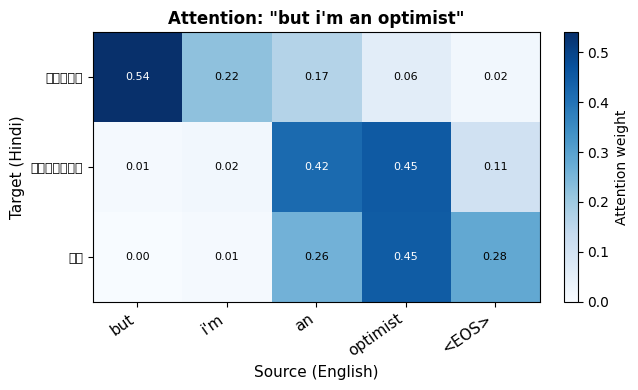


EN: "9 women is respectable"  →  HI: ""


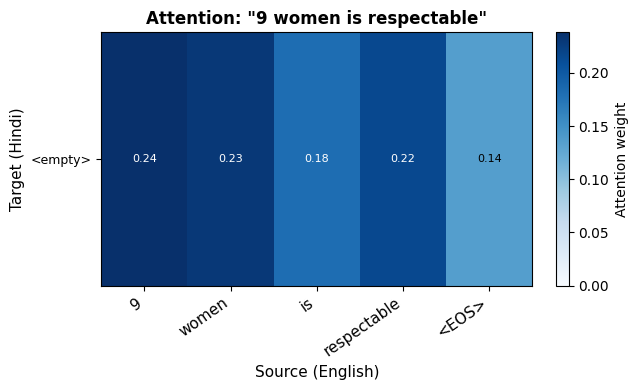


EN: "you cannot be celebrating that"  →  HI: "आप आप"


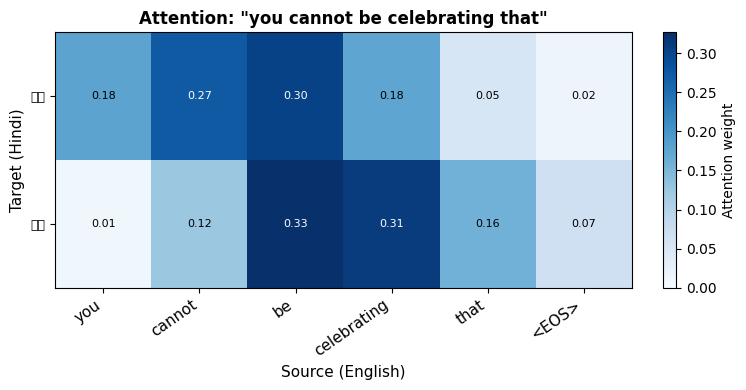

In [9]:
def plot_attention(mat, src_words, tgt_words, title='Attention', save=None):
    """
    Rows = target tokens (Hindi), Cols = source tokens (English)
    Bright = high attention. Diagonal pattern = good alignment.
    Note: Hindi labels show as boxes on Windows without Noto Sans Devanagari.
    """
    src_lab = src_words + ['<EOS>']
    h = min(len(mat), len(tgt_words))
    w = min(mat.shape[1] if h>0 else 1, len(src_lab))
    data = mat[:h, :w]

    fig, ax = plt.subplots(figsize=(max(6, w*1.1+1), max(4, h*0.5+1)))
    im = ax.imshow(data, cmap='Blues', aspect='auto', vmin=0, vmax=data.max()+1e-8)
    plt.colorbar(im, ax=ax, fraction=0.03, label='Attention weight')
    ax.set_xticks(range(w)); ax.set_xticklabels(src_lab[:w], rotation=35, ha='right', fontsize=11)
    ax.set_yticks(range(h)); ax.set_yticklabels(tgt_words[:h], fontsize=9)
    for i in range(h):
        for j in range(w):
            v=data[i,j]
            ax.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=8,
                    color='white' if v>data.max()*0.6 else 'black')
    ax.set_xlabel('Source (English)',fontsize=11)
    ax.set_ylabel('Target (Hindi)',  fontsize=11)
    ax.set_title(title,fontsize=12,fontweight='bold')
    plt.tight_layout()
    if save: plt.savefig(save,dpi=130,bbox_inches='tight')
    return fig

# Pick short sentences for cleaner visuals
viz = [en for en,_ in test_pairs if 2<=len(en.split())<=5][:5]
if not viz: viz=[en for en,_ in test_pairs[:5]]

for sent in viz:
    trans, attn_mat, src_w = translate_attn(sent, return_attn=True)
    tgt_w = trans.split() if trans else ['<empty>']
    print(f'EN: "{sent}"  →  HI: "{trans}"')
    if len(attn_mat)>0 and attn_mat.max()>0:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fig=plot_attention(attn_mat,src_w,tgt_w,
                               title=f'Attention: "{sent}"',
                               save=f'lab7_attn_{sent.split()[0]}.png')
            plt.show()
    print()


## Cell 10 — Summary Bar Chart

C:\Users\jaden\AppData\Local\Temp\ipykernel_3184\1602245786.py:13: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_title(metric,fontsize=11); ax.set_ylim(0,max(vals)*1.25)


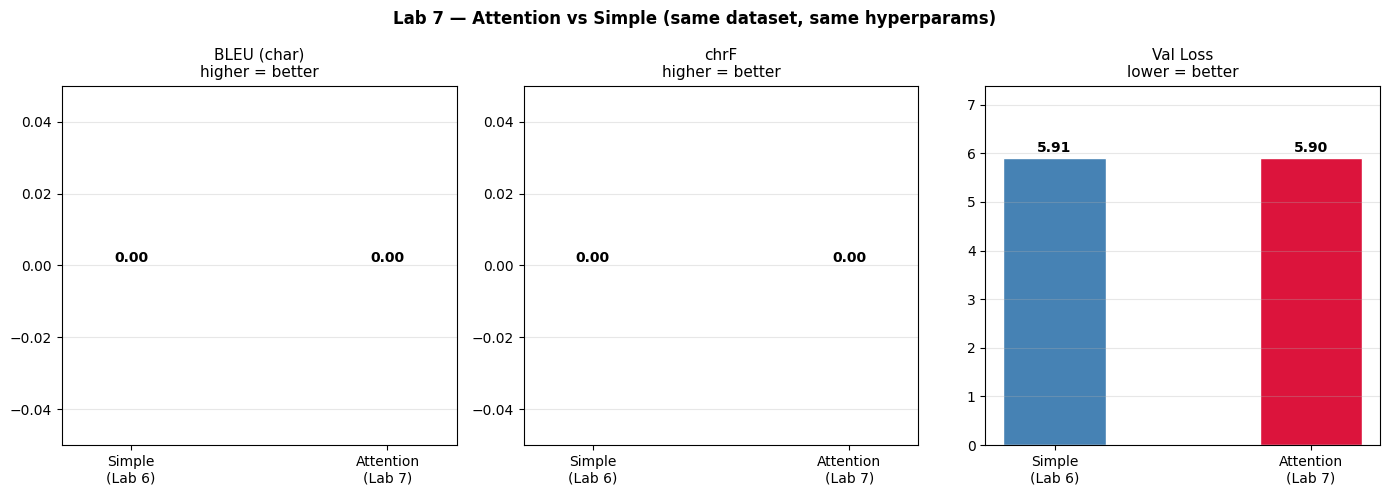

In [10]:
fig, axes = plt.subplots(1,3,figsize=(14,5))
metrics_data = {
    'BLEU (char)\nhigher = better': (simp_bleu.score, attn_bleu.score),
    'chrF\nhigher = better':        (simp_chrf.score, attn_chrf.score),
    'Val Loss\nlower = better':     (simp_best,        attn_best),
}
for ax,(metric,vals) in zip(axes, metrics_data.items()):
    bars=ax.bar(['Simple\n(Lab 6)','Attention\n(Lab 7)'],vals,
               color=['steelblue','crimson'],width=0.4,edgecolor='white')
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{val:.2f}',ha='center',va='bottom',fontweight='bold')
    ax.set_title(metric,fontsize=11); ax.set_ylim(0,max(vals)*1.25)
    ax.grid(axis='y',alpha=0.3)

plt.suptitle('Lab 7 — Attention vs Simple (same dataset, same hyperparams)',
             fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('lab7_comparison.png',dpi=150,bbox_inches='tight')
plt.show()


## Cell 11 — Gradio Frontend (Task 4)

In [11]:
import gradio as gr, tempfile

EXAMPLES=['how are you','good morning','thank you','what is your name',
          'i love india','water is important']

def run_translation(text, model_choice):
    if not text or not text.strip():
        return '⚠️ Enter English text.', None, '—'

    use_attn = model_choice == 'Attention (Lab 7)'

    if use_attn:
        trans, attn_mat, src_w = translate_attn(text, return_attn=True)
    else:
        trans = translate_simple(text)
        attn_mat, src_w = None, None

    # Both-model comparison
    at = translate_attn(text) if not use_attn else trans
    st = translate_simple(text) if use_attn else trans
    compare = f'Attention → {at}\nSimple    → {st}'

    # Image
    img = None
    if use_attn and attn_mat is not None and len(attn_mat)>0 and attn_mat.max()>0:
        tgt_w = trans.split() if trans else ['<empty>']
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fig=plot_attention(attn_mat,src_w,tgt_w,title=f'"{text}" → "{trans}"')
            tmp=tempfile.NamedTemporaryFile(suffix='.png',delete=False)
            fig.savefig(tmp.name,dpi=130,bbox_inches='tight')
            plt.close(fig); img=tmp.name
    elif not use_attn:
        fig,ax=plt.subplots(figsize=(5,2))
        ax.text(0.5,0.5,'Simple model uses a fixed context\nvector — no attention map.',
                ha='center',va='center',fontsize=12,color='steelblue',transform=ax.transAxes)
        ax.axis('off')
        tmp=tempfile.NamedTemporaryFile(suffix='.png',delete=False)
        fig.savefig(tmp.name,bbox_inches='tight'); plt.close(fig); img=tmp.name

    return trans or '—', img, compare


with gr.Blocks(title='Attention Translator — Lab 7',
               theme=gr.themes.Soft(primary_hue='violet')) as demo:
    gr.Markdown("""
    # 🔍 Attention Encoder-Decoder — EN → HI Translator
    **Lab 7 | Bahdanau Attention | ATML, NMIMS**
    Translate English → Hindi and visualise where the model pays attention.
    """)
    with gr.Row():
        with gr.Column(scale=1):
            inp   = gr.Textbox(label='English Input',placeholder='Type English…',lines=3,value='how are you')
            radio = gr.Radio(['Attention (Lab 7)','Simple (Lab 6)'],value='Attention (Lab 7)',label='Model')
            btn   = gr.Button('Translate',variant='primary',size='lg')
            gr.Markdown('### Examples')
            ex_btns=[gr.Button(e,size='sm') for e in EXAMPLES]
            gr.Markdown(f"""
            **Model info**
            - Trained on {len(train_pairs):,} EN→HI pairs
            - {CFG['n_layers']}-layer LSTM, hidden={CFG['hidden_dim']}
            - Best Attention PPL: {math.exp(min(attn_best,10)):.2f}
            - Best Simple PPL:    {math.exp(min(simp_best,10)):.2f}
            """)
        with gr.Column(scale=2):
            out_t = gr.Textbox(label='Hindi Translation',lines=2)
            out_c = gr.Textbox(label='Both Models',lines=3)
            out_i = gr.Image(label='Attention Heatmap (rows=Hindi, cols=English)')
            gr.Markdown('*Bright = high attention. Diagonal = good word alignment. Hindi labels may show as boxes on Windows — install Noto Sans Devanagari to fix.*')

    btn.click(run_translation,[inp,radio],[out_t,out_i,out_c])
    inp.submit(run_translation,[inp,radio],[out_t,out_i,out_c])
    for b,ex in zip(ex_btns,EXAMPLES):
        b.click(fn=lambda t=ex: run_translation(t,'Attention (Lab 7)'),
                outputs=[out_t,out_i,out_c]
               ).then(fn=lambda t=ex:t, outputs=inp)

    gr.Markdown('---\n*SVKM NMIMS — Advanced Topics in Machine Learning*')

demo.launch(share=False, debug=False)
# Use share=True for a public link


C:\Users\jaden\AppData\Local\Temp\ipykernel_3184\1169005363.py:44: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title='Attention Translator — Lab 7',


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Conclusion

| | Simple (Lab 6) | Attention (Lab 7) |
|---|---|---|
| Context at each step | Fixed (final encoder hidden) | Dynamic (weighted sum of all encoder states) |
| Information bottleneck | Yes | No |
| Interpretability | None | Attention heatmap shows alignment |
| Handles long sentences | Poorly | Better |

**Bahdanau Attention:**
```
e_ij  = V · tanh( W_dec·s_{i-1} + W_enc·h_j )    alignment score
α_ij  = softmax(e_ij)                              attention weights
c_i   = Σ_j α_ij · h_j                            context vector
```
The heatmap visualises α — a diagonal pattern means the model learned correct word-level alignment.